# Condorcet, cycles and paradoxes

The rules in this project read a **profile of rankings**, not a matrix of
distances. That is what lets Condorcet methods exist here at all: Copeland,
Maxmin and Ranked pairs are all different readings of one object, the pairwise
majority matrix, and there is no way to write them against voter-candidate
distances without rebuilding the rankings first.

This notebook uses that layer for the questions in `research/`:

1. what a Condorcet cycle looks like,
2. how to build *any* pattern of duels you like,
3. how often the Borda paradox shows up in Euclidean elections,
4. which rules actually elect the Condorcet winner,
5. how to construct an electorate with a Condorcet winner you choose.


In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from voting import (
    CopelandRule,
    InstantRunoffRule,
    LpModel,
    MaxminRule,
    Profile,
    RankedPairsRule,
    BordaRule,
    PluralityRule,
    VetoRule,
    is_borda_paradox,
    satisfies_condorcet,
)

from voting.plotting import plot_election, plot_majority_graph


## 1. A Condorcet cycle

Three groups of voters, none of them irrational, and yet the majorities run in a
circle: 0 beats 1, 1 beats 2, and 2 beats 0. No candidate beats everybody, so
there is no Condorcet winner to elect.


pairwise[a, b] = voters preferring a to b
[[0 8 5]
 [4 0 9]
 [7 3 0]]

Condorcet winner: None
cycle present:    True


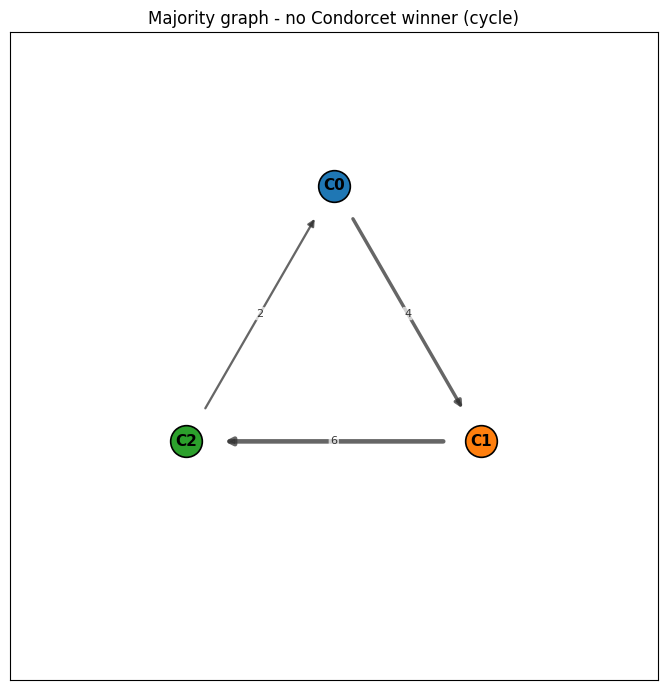

<Axes: title={'center': 'Majority graph - no Condorcet winner (cycle)'}>

In [2]:
cycle = Profile.from_counts({(0, 1, 2): 5, (1, 2, 0): 4, (2, 0, 1): 3})

print("pairwise[a, b] = voters preferring a to b")
print(cycle.pairwise)
print()
print("Condorcet winner:", cycle.condorcet_winner())
print("cycle present:   ", cycle.has_condorcet_cycle())

plot_majority_graph(cycle)


The Condorcet methods disagree about what to do with a cycle, which is
precisely why there are several of them.


In [3]:
for rule in (CopelandRule(), MaxminRule(), RankedPairsRule(), InstantRunoffRule()):
    print(f"{rule.name:22s} winner C{rule.winner(cycle)}   scores {rule.scores(cycle)}")


Copeland               winner C0   scores [0 0 0]
Maxmin                 winner C0   scores [5. 4. 3.]
Ranked pairs           winner C0   scores [2 1 0]
Instant-runoff (STV)   winner C0   scores [2 1 0]


## 2. Any tournament you like

McGarvey's construction builds a profile realizing *any* pattern of pairwise
victories. For each duel it adds two voters whose rankings are mirror images
except for that one pair, so every other majority cancels out.

Here is a four-way cycle, which no set of points in the plane would give you by
accident.


12 voters realize it exactly: True


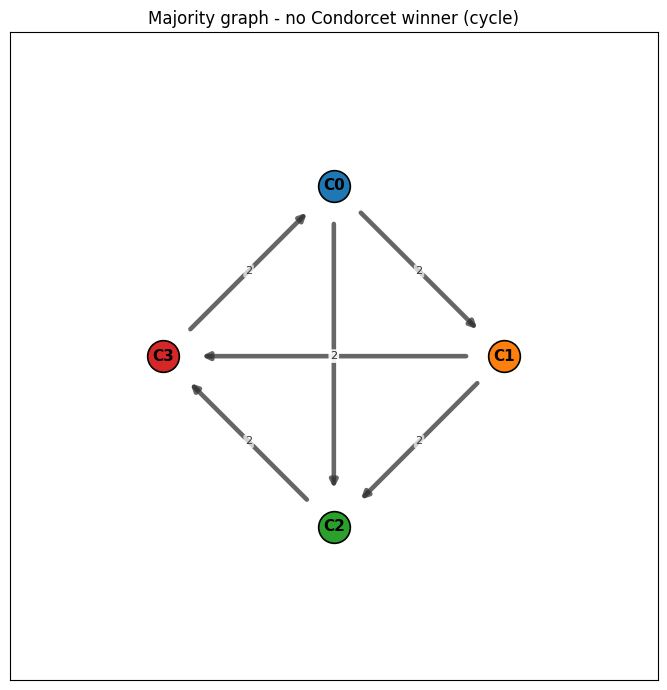

<Axes: title={'center': 'Majority graph - no Condorcet winner (cycle)'}>

In [4]:
wanted = np.zeros((4, 4), dtype=bool)
for a in range(4):
    wanted[a, (a + 1) % 4] = True   # 0 > 1 > 2 > 3 > 0
wanted[0, 2] = wanted[1, 3] = True  # and the two diagonals

built = Profile.from_tournament(wanted)
print(f"{built.n_voters} voters realize it exactly:", np.array_equal(built.beats(), wanted))

plot_majority_graph(built)


## 3. The Borda paradox in Euclidean elections

A candidate wins on first preferences while losing *every* head-to-head duel.
Clustered voters make it possible: the clusters split their support between
nearby candidates, and a candidate nobody would choose one-on-one comes through
the middle.


In [5]:
def clustered_election(rng, n_candidates=4, n_voters=120, n_clusters=3, spread=1.5):
    """Candidates uniform on the board, voters in a few Gaussian clumps."""
    candidates = rng.uniform(-10, 10, (n_candidates, 2))
    centers = rng.uniform(-8, 8, (n_clusters, 2))
    pick = rng.integers(0, n_clusters, n_voters)
    voters = centers[pick] + rng.normal(0, spread, (n_voters, 2))
    return candidates, voters


rng = np.random.default_rng(0)
paradoxes, cycles, examples = 0, 0, []

for _ in range(400):
    candidates, voters = clustered_election(rng)
    profile = Profile.from_positions(voters, candidates)
    cycles += profile.has_condorcet_cycle()
    if is_borda_paradox(profile):
        paradoxes += 1
        examples.append((candidates, voters, profile))

print(f"Borda paradox:     {paradoxes}/400 elections")
print(f"Condorcet cycles:  {cycles}/400 elections")


Borda paradox:     5/400 elections
Condorcet cycles:  6/400 elections


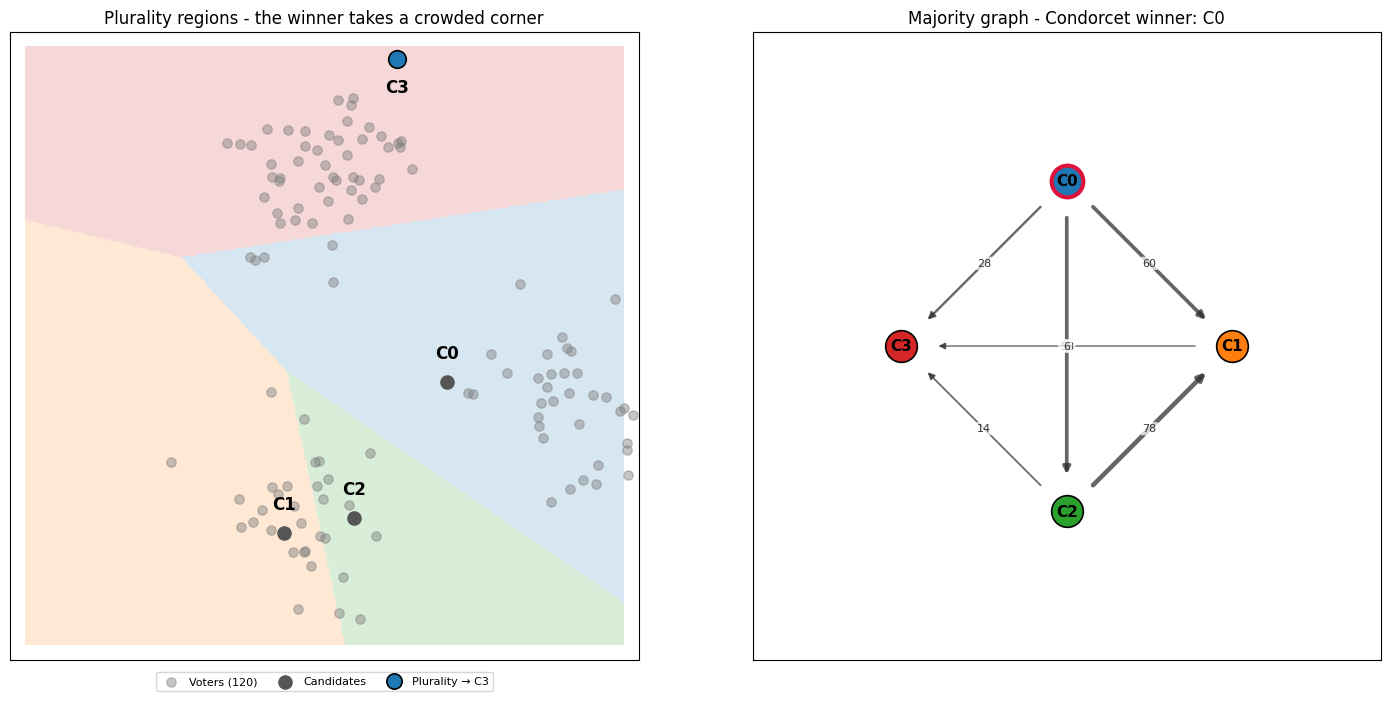

plurality winner: C3
Condorcet loser:  C3


In [6]:
# The first example, seen twice: where the voters stand, and who beats whom.
candidates, voters, profile = examples[0]

fig, (left, right) = plt.subplots(1, 2, figsize=(15, 7))
plot_election(
    candidates,
    voters,
    {"plurality": PluralityRule().winner(profile)},
    regions=True,
    ax=left,
    title="Plurality regions - the winner takes a crowded corner",
)
plot_majority_graph(profile, ax=right)
plt.tight_layout()
plt.show()

print("plurality winner: C", PluralityRule().winner(profile), sep="")
print("Condorcet loser:  C", profile.condorcet_loser(), sep="")


## 4. Which rules elect the Condorcet winner?

The Condorcet methods do by construction - that is what makes them Condorcet
methods. The interesting numbers are the others: how often plurality, Borda,
veto and STV happen to agree when a Condorcet winner exists.


In [7]:
rules = [
    PluralityRule(),
    BordaRule(),
    VetoRule(),
    InstantRunoffRule(),
    CopelandRule(),
    MaxminRule(),
    RankedPairsRule(),
]

rng = np.random.default_rng(1)
agreed = {rule.key: 0 for rule in rules}
decidable = 0

for _ in range(300):
    candidates, voters = clustered_election(rng)
    profile = Profile.from_positions(voters, candidates)
    if profile.condorcet_winner() is None:
        continue  # nothing to agree with
    decidable += 1
    for rule in rules:
        agreed[rule.key] += bool(satisfies_condorcet(rule, profile))

print(f"{decidable} of 300 elections had a Condorcet winner\n")
print(f"{'rule':<24}{'elects it':>10}")
for rule in rules:
    share = agreed[rule.key] / decidable
    print(f"{rule.name:<24}{share:>9.0%}")


287 of 300 elections had a Condorcet winner

rule                     elects it
Plurality                     86%
Borda count                   90%
Veto                          45%
Instant-runoff (STV)          92%
Copeland                     100%
Maxmin                       100%
Ranked pairs                 100%


## 5. Building an electorate with a chosen Condorcet winner

"Candidate *j* beats everyone head to head" is a linear condition on the number
of voters holding each ranking, so the integer program can be asked for it
directly - one constraint per duel, exactly as in the notes.


In [8]:
candidates = np.random.default_rng(5).uniform(-9, 9, (4, 2))

for target in range(len(candidates)):
    model = LpModel(
        candidates=candidates,
        condorcet_winner=target,
        n_voters=200,
        pool_size=60_000,
        rng=np.random.default_rng(6),
    )
    status = model.solve()
    got = model.solution_profile().condorcet_winner() if status == "Optimal" else None
    print(f"asked for C{target}: {status:<12} got C{got}")


asked for C0: Optimal      got C0
asked for C1: Optimal      got C1
asked for C2: Optimal      got C2
asked for C3: Optimal      got C3


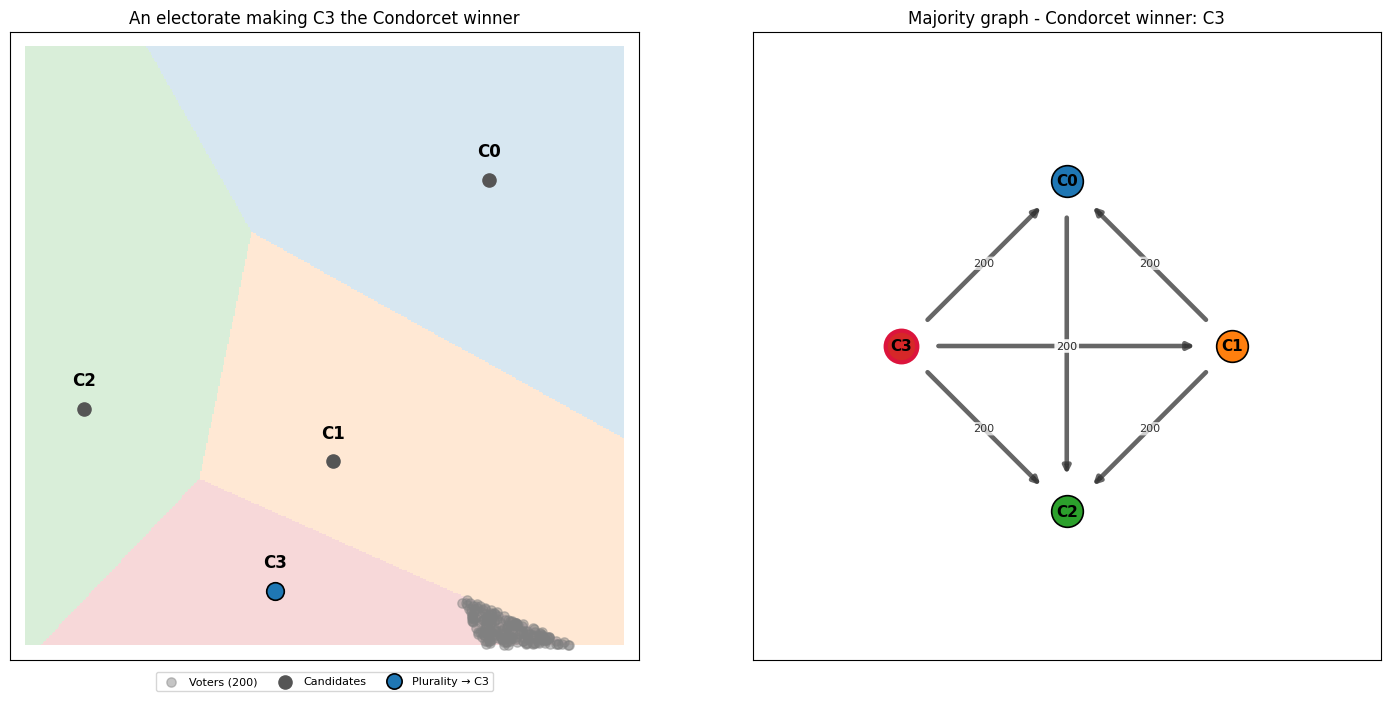

In [9]:
# The last electorate built above, and the duels it produces.
voters = model.generate_voter_positions()
profile = Profile.from_positions(voters, candidates)

fig, (left, right) = plt.subplots(1, 2, figsize=(15, 7))
plot_election(
    candidates,
    voters,
    {"plurality": PluralityRule().winner(profile)},
    regions=True,
    ax=left,
    title=f"An electorate making C{target} the Condorcet winner",
)
plot_majority_graph(profile, ax=right)
plt.tight_layout()
plt.show()
